In [3]:
import glob
import pandas as pd
import numpy as np
import os
import tqdm
import re
from matplotlib import pyplot as plt
file_pattern="dated_Turb*.csv"

import warnings
warnings.filterwarnings("ignore")

# 设置中文字体
# 设置中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [4]:
def load_wind_speed_data(path, train_ratio=0.7, feature_col="Wspd"):
        """
        从CSV文件加载风速数据
        
        Parameters:
        path: 文件夹路径
        train_ratio: 训练集比例
        feature_col: 特征列名
        
        Returns:
        numpy array: 风速数据矩阵 [num_turbines, timesteps]
        """
        data_files = glob.glob(os.path.join(path, file_pattern))
        # 提取Turb后面的数字进行排序
        def extract_turb_num(filename):
            basename = os.path.basename(filename)
            match = re.search(r'Turb(\d+)', basename)
            return int(match.group(1)) if match else float('inf')
        data_files.sort(key=extract_turb_num)
        
        if len(data_files) == 0:
            raise ValueError(f"未找到匹配的数据文件: {os.path.join(path, file_pattern)}")
        
        print(f"找到 {len(data_files)} 个风速数据文件")
        # 读取第一个文件确定数据长度
        sample_df = pd.read_csv(data_files[0])
        total_timesteps = len(sample_df)
        train_split = int(train_ratio * total_timesteps)
        print(f"总时间步数: {total_timesteps}, 训练集时间步数: {train_split}")
        
        # 检查特征列是否存在
        if feature_col not in sample_df.columns:
            print(f"特征列 '{feature_col}' 不存在，可用列: {list(sample_df.columns)}")
            raise ValueError(f"特征列 '{feature_col}' 不存在")
        print("目标特征:", feature_col)
        # 初始化数组
        target_series = np.zeros((len(data_files), train_split))
        
        # 加载数据
        for i, file in enumerate(tqdm.tqdm(data_files, desc="加载数据")):
            try:
                df = pd.read_csv(file)
                df = df.fillna(0)
                
                # 检查数据长度
                if len(df) != total_timesteps:
                    print(f"警告: 文件 {file} 的数据长度不一致")
                    min_length = min(len(df), train_split)
                    target_series[i, :min_length] = df[feature_col].iloc[:min_length].values
                else:
                    target_series[i, :] = df[feature_col].iloc[:train_split].values
            except Exception as e:
                print(f"读取文件 {file} 时出错: {e}")

        print(f"数据加载完成: {target_series.shape}")
        return target_series

In [5]:
def compute_correlation_matrix(data, method="pearson", use_abs=False):
    """
    计算风机间的相关性矩阵
    
    Parameters:
    data: numpy array, 风速数据矩阵 [num_turbines, timesteps]
    method: 相关性计算方法 ('pearson', 'pearson_diff', 'pearson_dir')
    use_abs: 是否使用绝对值相关性
    
    Returns:
    numpy array: 相关性矩阵
    """
    if data is None:
        raise ValueError("无风速数据，无法计算相关性矩阵")
    print(f"正在计算相关性矩阵 (方法: {method})...")
    # 数据质量检查
    print("数据质量检查:")
    zero_variance_turbines = []
    for i in range(data.shape[0]):
        data1 = data[i, :]
        std_val = np.std(data1)
        if std_val == 0:
            print(f"警告: 风机 {i} 的风速数据方差为0 (均值: {np.mean(data1):.2f})")
            zero_variance_turbines.append(i)

    # 计算相关性矩阵
    print(f"原始数据形状: {data.shape}")

    #预处理
    processed_data = data
    if method == "pearson_diff":
        # 计算一阶差分
        processed_data = np.diff(data, axis=1)
        print(f"差分数据形状: {processed_data.shape}")
    elif method == "pearson_dir":
        # 计算风速数据的方向
        def angle_to_vector(angles):
            """将角度转换为单位向量"""
            angles_rad = np.radians(angles)
            x = np.cos(angles_rad)  # 范围[-1, 1]
            y = np.sin(angles_rad)  # 范围[-1, 1]
            return x, y
        processed_data = angle_to_vector(data)
        print(f"方向数据形状: {len(processed_data)}")

    # 计算相关性
    if method == "pearson" or method == "pearson_diff":
        correlation_matrix = np.corrcoef(processed_data)
    elif method == "pearson_dir":
        cos_correlation_matrix = np.corrcoef(processed_data[0])
        sin_correlation_matrix = np.corrcoef(processed_data[1])
        correlation_matrix = (cos_correlation_matrix + sin_correlation_matrix) / 2

    # 处理NaN值
    nan_mask = np.isnan(correlation_matrix)
    if np.any(nan_mask):
        print("发现相关性矩阵中有NaN值，进行处理...")
        correlation_matrix = np.nan_to_num(correlation_matrix, nan=0.0)
        # 重新设置对角线为1
        np.fill_diagonal(correlation_matrix, 1.0)
    
    # 使用绝对值相关性
    if use_abs:
        correlation_matrix = np.abs(correlation_matrix)
        print("使用绝对值相关性")
    
    # 设置对角线为0（用于图构建）
    np.fill_diagonal(correlation_matrix, 0)

    return correlation_matrix
    
def print_correlation_stats(correlation_matrix):
    num_nodes = correlation_matrix.shape[0]
    """打印相关性统计信息"""
    # 获取上三角矩阵的相关性值（排除对角线）
    corr_values = correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]
    
    print("\n=== 相关性统计信息 ===")
    print(f"相关系数范围: [{np.min(corr_values):.3f}, {np.max(corr_values):.3f}]")
    print(f"平均相关系数: {np.mean(corr_values):.3f}")
    print(f"相关系数标准差: {np.std(corr_values):.3f}")
    print(f"中位数相关系数: {np.median(corr_values):.3f}")
    
    # 相关性分布统计
    strong_corr = np.sum(np.abs(corr_values) > 0.7)
    medium_corr = np.sum((np.abs(corr_values) > 0.4) & (np.abs(corr_values) <= 0.7))
    weak_corr = np.sum((np.abs(corr_values) > 0.2) & (np.abs(corr_values) <= 0.4))
    very_weak_corr = np.sum(np.abs(corr_values) <= 0.2)
    
    total_pairs = len(corr_values)
    print(f"\n相关性强度分布:")
    print(f"  强相关 (>0.7): {strong_corr}/{total_pairs} ({strong_corr/total_pairs*100:.1f}%)")
    print(f"  中等相关 (0.4-0.7): {medium_corr}/{total_pairs} ({medium_corr/total_pairs*100:.1f}%)")
    print(f"  弱相关 (0.2-0.4): {weak_corr}/{total_pairs} ({weak_corr/total_pairs*100:.1f}%)")
    print(f"  很弱相关 (≤0.2): {very_weak_corr}/{total_pairs} ({very_weak_corr/total_pairs*100:.1f}%)")
    
    # 不同阈值下的连接统计
    thresholds = [0.3, 0.5, 0.7, 0.8, 0.9]
    print(f"\n不同阈值下的连接统计:")
    for thresh in thresholds:
        connections = np.sum(np.abs(correlation_matrix) > thresh) // 2  # 除以2因为对称
        total_possible = num_nodes * (num_nodes - 1) // 2
        ratio = connections / total_possible * 100 if total_possible > 0 else 0
        print(f"  阈值 {thresh:.1f}: {connections}/{total_possible} ({ratio:.1f}%) 连接")

def visualize_correlation_matrix(correlation_matrix, save_path="correlation_matrix.png", figsize=(12, 10)):
    """
    可视化相关性矩阵
    
    Parameters:
    correlation_matrix: 相关性矩阵
    save_path: 保存路径
    figsize: 图像大小
    """
    
    plt.figure(figsize=figsize)
    
    # 创建相关性矩阵的副本用于显示（恢复对角线为1）
    display_matrix = correlation_matrix.copy()
    np.fill_diagonal(display_matrix, 1.0)
    
    # 绘制热力图
    im = plt.imshow(display_matrix, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')
    
    plt.colorbar(im, label='相关系数')
    plt.title('风速相关性矩阵')
    plt.xlabel('风机ID')
    plt.ylabel('风机ID')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"相关性矩阵图已保存为 {save_path}")

## 1. Original

In [4]:
wind_speed = load_wind_speed_data("/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/dataset/spatial_wind",feature_col="Wspd")
original_wind_direction = load_wind_speed_data("/mnt/EDisk/MyProject/WindSeedForecasting/Time-Series-Library/dataset/spatial_wind",feature_col="Wdir")
wind_direction = original_wind_direction % 360

找到 134 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696
目标特征: Wspd


加载数据: 100%|██████████| 134/134 [00:15<00:00,  8.92it/s]


数据加载完成: (134, 24696)
找到 134 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696
目标特征: Wdir


加载数据: 100%|██████████| 134/134 [00:20<00:00,  6.55it/s]


数据加载完成: (134, 24696)


(134, 24696) (134, 24696)
正在计算相关性矩阵 (方法: pearson)...
数据质量检查:
原始数据形状: (134, 24696)

=== 相关性统计信息 ===
相关系数范围: [0.775, 0.985]
平均相关系数: 0.927
相关系数标准差: 0.028
中位数相关系数: 0.931

相关性强度分布:
  强相关 (>0.7): 8911/8911 (100.0%)
  中等相关 (0.4-0.7): 0/8911 (0.0%)
  弱相关 (0.2-0.4): 0/8911 (0.0%)
  很弱相关 (≤0.2): 0/8911 (0.0%)

不同阈值下的连接统计:
  阈值 0.3: 8911/8911 (100.0%) 连接
  阈值 0.5: 8911/8911 (100.0%) 连接
  阈值 0.7: 8911/8911 (100.0%) 连接
  阈值 0.8: 8888/8911 (99.7%) 连接
  阈值 0.9: 7649/8911 (85.8%) 连接


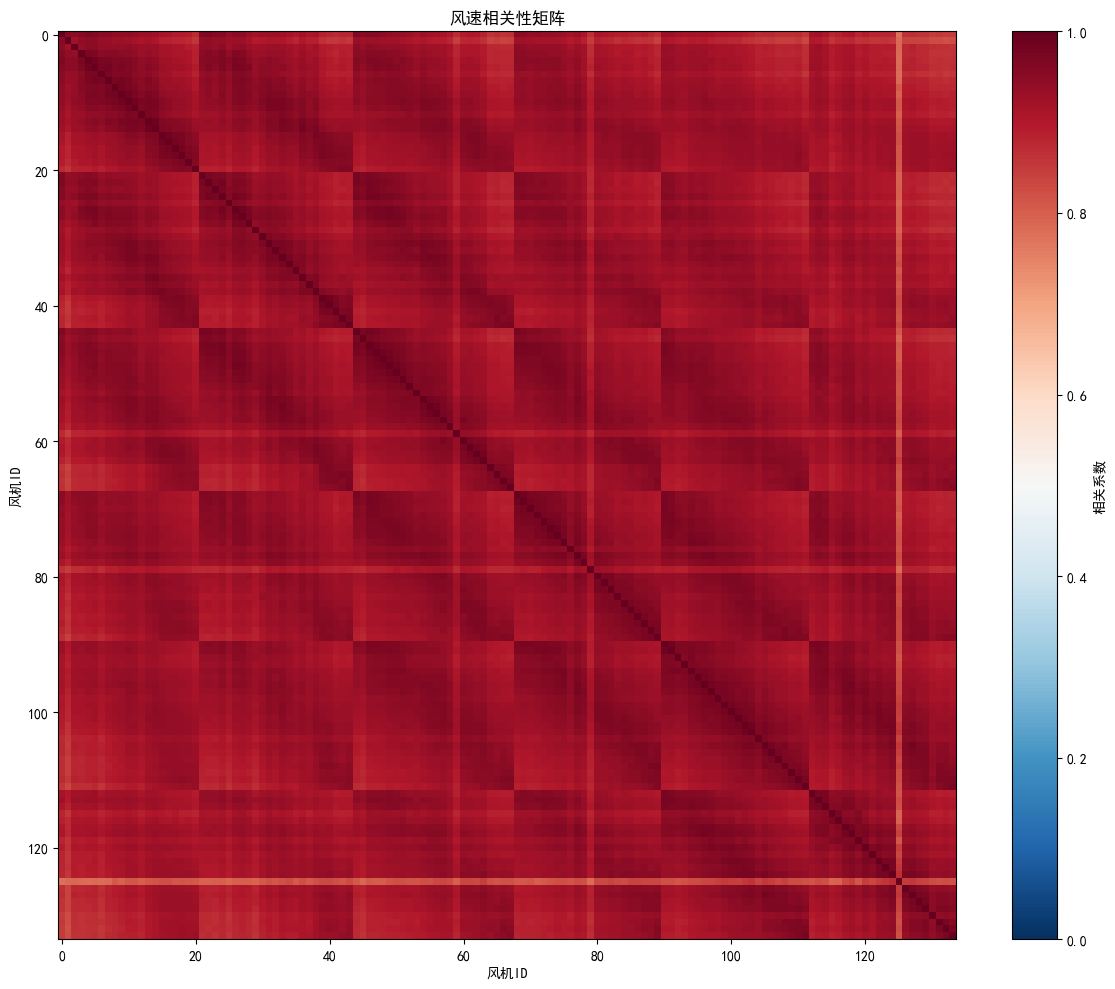

相关性矩阵图已保存为 wind_speed_correlation_matrix.png
正在计算相关性矩阵 (方法: pearson_diff)...
数据质量检查:
原始数据形状: (134, 24696)
差分数据形状: (134, 24695)

=== 相关性统计信息 ===
相关系数范围: [-0.028, 0.772]
平均相关系数: 0.291
相关系数标准差: 0.135
中位数相关系数: 0.249

相关性强度分布:
  强相关 (>0.7): 101/8911 (1.1%)
  中等相关 (0.4-0.7): 1583/8911 (17.8%)
  弱相关 (0.2-0.4): 4674/8911 (52.5%)
  很弱相关 (≤0.2): 2553/8911 (28.6%)

不同阈值下的连接统计:
  阈值 0.3: 3182/8911 (35.7%) 连接
  阈值 0.5: 843/8911 (9.5%) 连接
  阈值 0.7: 101/8911 (1.1%) 连接
  阈值 0.8: 0/8911 (0.0%) 连接
  阈值 0.9: 0/8911 (0.0%) 连接


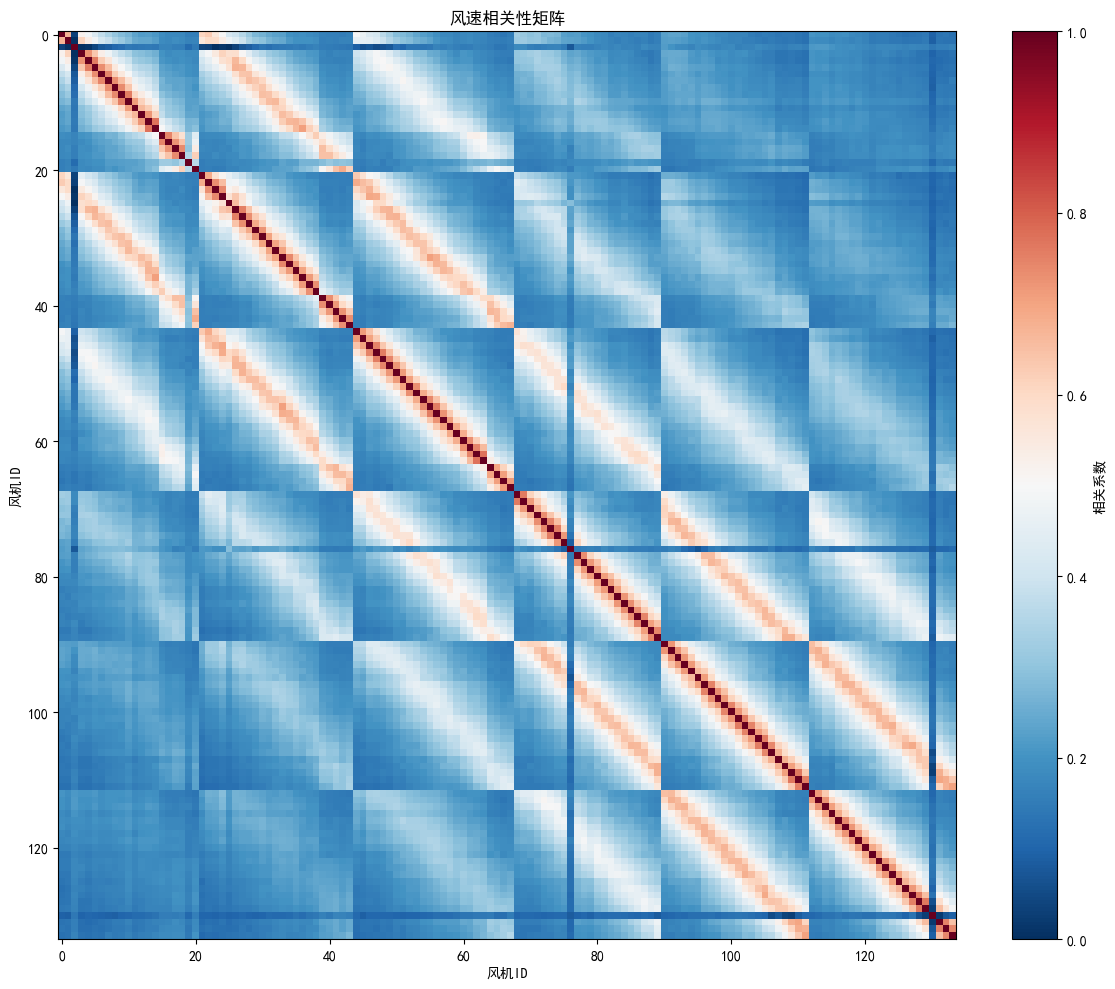

相关性矩阵图已保存为 wind_speed_diff_correlation_matrix.png
正在计算相关性矩阵 (方法: pearson_dir)...
数据质量检查:
原始数据形状: (134, 24696)
方向数据形状: 2

=== 相关性统计信息 ===
相关系数范围: [0.242, 0.752]
平均相关系数: 0.475
相关系数标准差: 0.082
中位数相关系数: 0.472

相关性强度分布:
  强相关 (>0.7): 43/8911 (0.5%)
  中等相关 (0.4-0.7): 7165/8911 (80.4%)
  弱相关 (0.2-0.4): 1703/8911 (19.1%)
  很弱相关 (≤0.2): 0/8911 (0.0%)

不同阈值下的连接统计:
  阈值 0.3: 8830/8911 (99.1%) 连接
  阈值 0.5: 3335/8911 (37.4%) 连接
  阈值 0.7: 43/8911 (0.5%) 连接
  阈值 0.8: 0/8911 (0.0%) 连接
  阈值 0.9: 0/8911 (0.0%) 连接


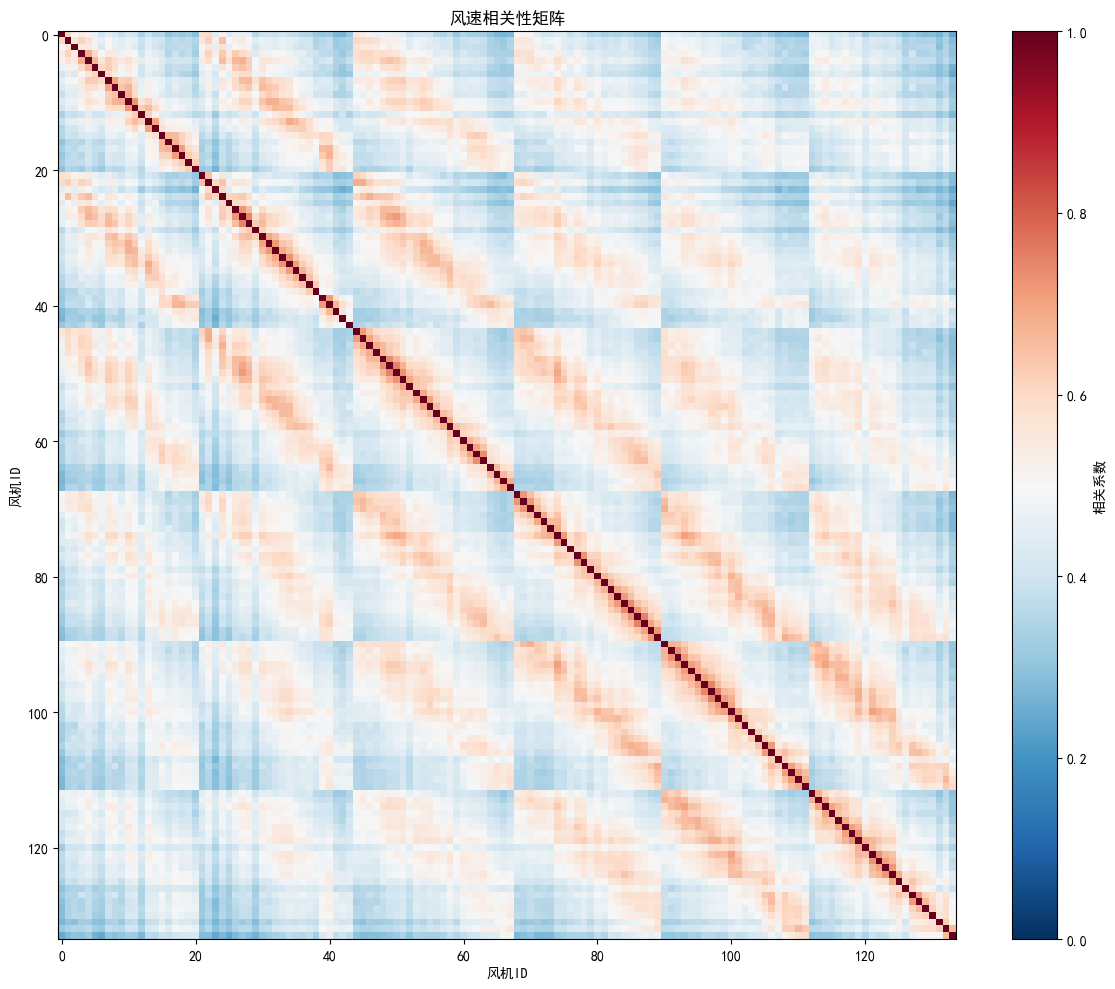

相关性矩阵图已保存为 wind_direction_correlation_matrix.png

=== 相关性统计信息 ===
相关系数范围: [0.318, 0.798]
平均相关系数: 0.492
相关系数标准差: 0.087
中位数相关系数: 0.474

相关性强度分布:
  强相关 (>0.7): 246/8911 (2.8%)
  中等相关 (0.4-0.7): 7552/8911 (84.7%)
  弱相关 (0.2-0.4): 1113/8911 (12.5%)
  很弱相关 (≤0.2): 0/8911 (0.0%)

不同阈值下的连接统计:
  阈值 0.3: 8911/8911 (100.0%) 连接
  阈值 0.5: 3412/8911 (38.3%) 连接
  阈值 0.7: 246/8911 (2.8%) 连接
  阈值 0.8: 0/8911 (0.0%) 连接
  阈值 0.9: 0/8911 (0.0%) 连接


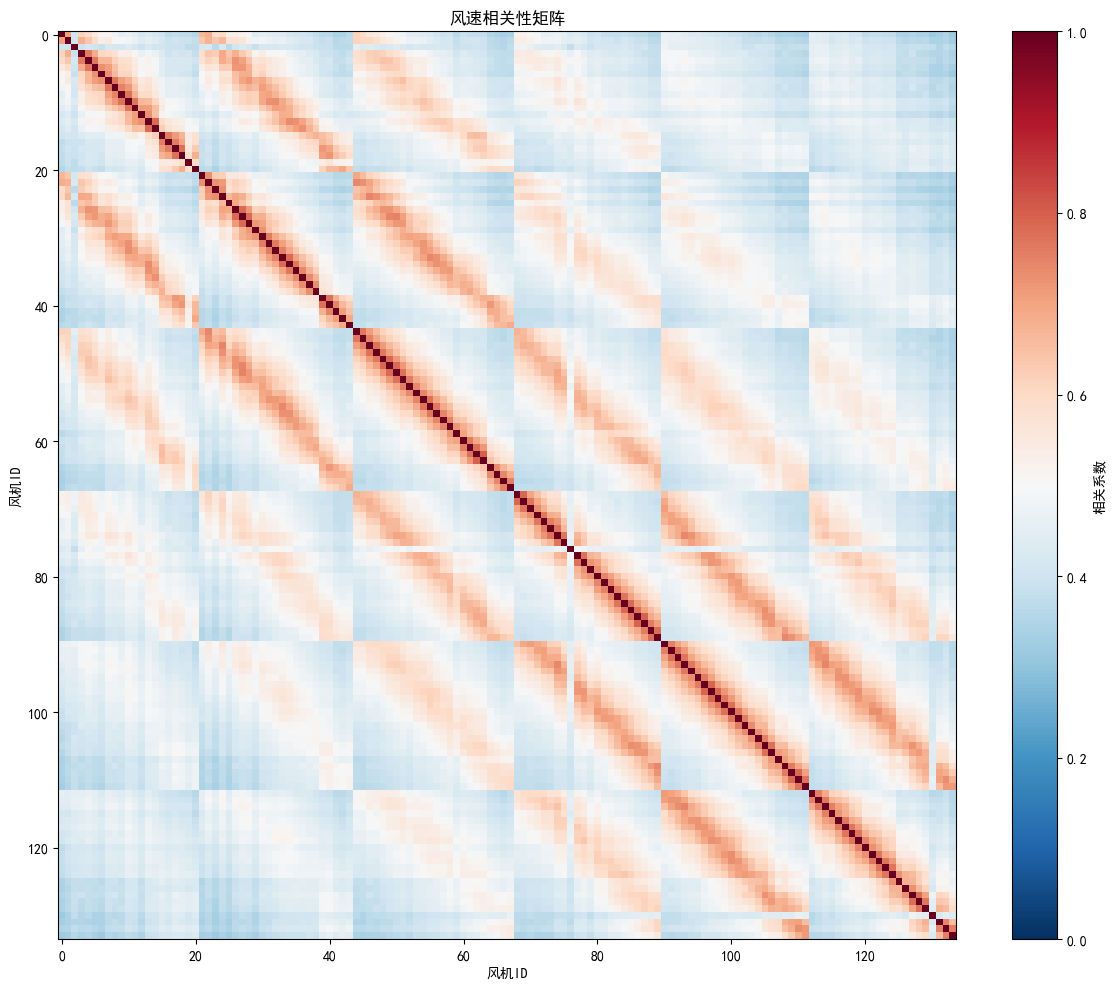

相关性矩阵图已保存为 weighted_correlation_matrix.png


In [5]:
print(wind_speed.shape, wind_direction.shape)

wind_corr = compute_correlation_matrix(wind_speed, method="pearson")
print_correlation_stats(wind_corr)
visualize_correlation_matrix(wind_corr, save_path="wind_speed_correlation_matrix.png")
np.savez("wind_speed_correlation_matrices.npz", original=wind_corr)

wind_diff_corr = compute_correlation_matrix(wind_speed, method="pearson_diff")
print_correlation_stats(wind_diff_corr)
visualize_correlation_matrix(wind_diff_corr, save_path="wind_speed_diff_correlation_matrix.png")
np.savez("wind_speed_diff_correlation_matrices.npz", original=wind_diff_corr)

wind_dir_corr = compute_correlation_matrix(wind_direction, method="pearson_dir")
print_correlation_stats(wind_dir_corr)
visualize_correlation_matrix(wind_dir_corr, save_path="wind_direction_correlation_matrix.png")
np.savez("wind_direction_correlation_matrices.npz", original=wind_dir_corr)

weighted_corr = (wind_corr * 0.2 + wind_diff_corr * 0.4 + wind_dir_corr * 0.4)
print_correlation_stats(weighted_corr)
visualize_correlation_matrix(weighted_corr, save_path="weighted_correlation_matrix.png")
np.savez("weighted_correlation_matrices.npz", original=weighted_corr)


## 2. 风向感知的

In [6]:
wind_speed = load_wind_speed_data("/mnt/EDisk/projects/WindSeedForecasting/Time-Series-Library/dataset/spatial_wind",feature_col="Wspd")
original_Ndir = load_wind_speed_data("/mnt/EDisk/projects/WindSeedForecasting/Time-Series-Library/dataset/spatial_wind",feature_col="Ndir")
original_Wdir = load_wind_speed_data("/mnt/EDisk/projects/WindSeedForecasting/Time-Series-Library/dataset/spatial_wind",feature_col="Wdir")


找到 134 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696
目标特征: Wspd


加载数据: 100%|██████████| 134/134 [00:09<00:00, 14.52it/s]


数据加载完成: (134, 24696)
找到 134 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696
目标特征: Ndir


加载数据: 100%|██████████| 134/134 [00:08<00:00, 15.33it/s]


数据加载完成: (134, 24696)
找到 134 个风速数据文件
总时间步数: 35280, 训练集时间步数: 24696
目标特征: Wdir


加载数据: 100%|██████████| 134/134 [00:10<00:00, 13.24it/s]

数据加载完成: (134, 24696)


In [7]:
wind_direction = (original_Ndir - original_Wdir + 360) % 360

In [8]:
def compute_weighted_global_wind_direction_and_sector(
    wind_direction,
    wind_speed,
    K=16,
    min_valid_ratio=0.5,
):
    N, T = wind_direction.shape
    
    # 确保角度在[0, 360)范围内
    wind_direction = wind_direction % 360
    
    theta_rad = np.deg2rad(wind_direction)
    
    # 计算单位向量
    u_unit = np.sin(theta_rad)   # 东分量单位向量
    v_unit = np.cos(theta_rad)   # 北分量单位向量
    
    # 无效值掩码
    valid_mask = (wind_speed > 0.1) & np.isfinite(wind_speed) & np.isfinite(wind_direction)
    
    global_dir = np.full(T, np.nan)
    consistency = np.full(T, np.nan)
    sector_id = np.full(T, -1, dtype=int)
    
    for t in range(T):
        mask_t = valid_mask[:, t]
        n_valid = np.sum(mask_t)
        if n_valid < max(1, min_valid_ratio * N):
            continue
        
        w = wind_speed[mask_t, t]
        
        # 计算加权平均的单位向量
        u_avg = np.sum(w * u_unit[mask_t, t]) / np.sum(w)
        v_avg = np.sum(w * v_unit[mask_t, t]) / np.sum(w)
        
        # 一致性就是单位向量的长度
        R = np.sqrt(u_avg**2 + v_avg**2)
        
        # 计算主导风向
        mean_dir_rad = np.arctan2(u_avg, v_avg)
        mean_dir_deg = np.rad2deg(mean_dir_rad)
        mean_dir_deg = (mean_dir_deg + 360) % 360
        
        global_dir[t] = mean_dir_deg
        consistency[t] = R
        
        # 分配扇区
        sector_width = 360.0 / K
        sec = int(mean_dir_deg // sector_width) % K
        sector_id[t] = sec
    
    return global_dir, sector_id, consistency

In [9]:
global_dir, sectors, consistency = compute_weighted_global_wind_direction_and_sector(wind_direction, wind_speed)
print("主导风向示例:", global_dir[:10])
print("扇区示例:", sectors[:10])
print("nan数量:", np.sum(np.isnan(global_dir)))
for i in range(16):
    count = np.sum(sectors == i)
    print(f"扇区 {i}: {count} 个时间步，占比 {count / len(sectors) * 100:.2f}%")
print("一致性示例:", consistency[:10])
print(f"一致性平均值:{np.nanmean(consistency)}, 一致性方差:{np.nanstd(consistency)}")
print(f"一致性最小值: {np.nanmin(consistency)}, 最大值: {np.nanmax(consistency)}")
print(f"<0.3 数量: {np.sum(consistency<0.3)}, 0.3-0.5 数量: {np.sum((consistency>=0.3)&(consistency<0.5))}, 0.5-0.7 数量: {np.sum((consistency>=0.5)&(consistency<0.7))}, >=0.7 数量: {np.sum(consistency>=0.7)}")

主导风向示例: [         nan   6.14657029   5.02329662   4.09131363   1.44677083
 358.54651659 357.2905931  359.6012511  357.46684221 358.31358466]
扇区示例: [-1  0  0  0  0 15 15 15 15 15]
nan数量: 267
扇区 0: 3871 个时间步，占比 15.67%
扇区 1: 1409 个时间步，占比 5.71%
扇区 2: 611 个时间步，占比 2.47%
扇区 3: 265 个时间步，占比 1.07%
扇区 4: 304 个时间步，占比 1.23%
扇区 5: 646 个时间步，占比 2.62%
扇区 6: 1651 个时间步，占比 6.69%
扇区 7: 2205 个时间步，占比 8.93%
扇区 8: 1165 个时间步，占比 4.72%
扇区 9: 971 个时间步，占比 3.93%
扇区 10: 895 个时间步，占比 3.62%
扇区 11: 696 个时间步，占比 2.82%
扇区 12: 598 个时间步，占比 2.42%
扇区 13: 1252 个时间步，占比 5.07%
扇区 14: 3461 个时间步，占比 14.01%
扇区 15: 4429 个时间步，占比 17.93%
一致性示例: [       nan 0.49936187 0.49787013 0.50605115 0.50558332 0.5136528
 0.50762984 0.51020082 0.51549394 0.51551909]
一致性平均值:0.40255899762010355, 一致性方差:0.08431596127363276
一致性最小值: 0.002069480870567176, 最大值: 0.5467625900468943
<0.3 数量: 2636, 0.3-0.5 数量: 20899, 0.5-0.7 数量: 894, >=0.7 数量: 0


In [10]:
for i in range(16):
    mask = (sectors == i) & (~np.isnan(consistency))
    if np.sum(mask) == 0:
        continue
    avg_consistency = np.nanmean(consistency[mask])
    print(f"扇区 {i}: 平均一致性 {avg_consistency:.4f}, 数量 {np.sum(mask)}")
    print(f"\t<0.3 数量: {np.sum(consistency[mask]<0.3)}, 0.3-0.5 数量: {np.sum((consistency[mask]>=0.3)&(consistency[mask]<0.5))}, 0.5-0.7 数量: {np.sum((consistency[mask]>=0.5)&(consistency[mask]<0.7))}, >=0.7 数量: {np.sum(consistency[mask]>=0.7)}")


扇区 0: 平均一致性 0.4244, 数量 3871
	<0.3 数量: 222, 0.3-0.5 数量: 3363, 0.5-0.7 数量: 286, >=0.7 数量: 0
扇区 1: 平均一致性 0.4003, 数量 1409
	<0.3 数量: 172, 0.3-0.5 数量: 1185, 0.5-0.7 数量: 52, >=0.7 数量: 0
扇区 2: 平均一致性 0.3750, 数量 611
	<0.3 数量: 114, 0.3-0.5 数量: 486, 0.5-0.7 数量: 11, >=0.7 数量: 0
扇区 3: 平均一致性 0.3274, 数量 265
	<0.3 数量: 82, 0.3-0.5 数量: 181, 0.5-0.7 数量: 2, >=0.7 数量: 0
扇区 4: 平均一致性 0.3194, 数量 304
	<0.3 数量: 116, 0.3-0.5 数量: 187, 0.5-0.7 数量: 1, >=0.7 数量: 0
扇区 5: 平均一致性 0.3723, 数量 646
	<0.3 数量: 125, 0.3-0.5 数量: 519, 0.5-0.7 数量: 2, >=0.7 数量: 0
扇区 6: 平均一致性 0.3970, 数量 1651
	<0.3 数量: 160, 0.3-0.5 数量: 1490, 0.5-0.7 数量: 1, >=0.7 数量: 0
扇区 7: 平均一致性 0.3974, 数量 2205
	<0.3 数量: 189, 0.3-0.5 数量: 2015, 0.5-0.7 数量: 1, >=0.7 数量: 0
扇区 8: 平均一致性 0.3743, 数量 1165
	<0.3 数量: 194, 0.3-0.5 数量: 970, 0.5-0.7 数量: 1, >=0.7 数量: 0
扇区 9: 平均一致性 0.3839, 数量 971
	<0.3 数量: 153, 0.3-0.5 数量: 813, 0.5-0.7 数量: 5, >=0.7 数量: 0
扇区 10: 平均一致性 0.3751, 数量 895
	<0.3 数量: 177, 0.3-0.5 数量: 711, 0.5-0.7 数量: 7, >=0.7 数量: 0
扇区 11: 平均一致性 0.3669, 数量 696
	<0.3 数量: 142

10000


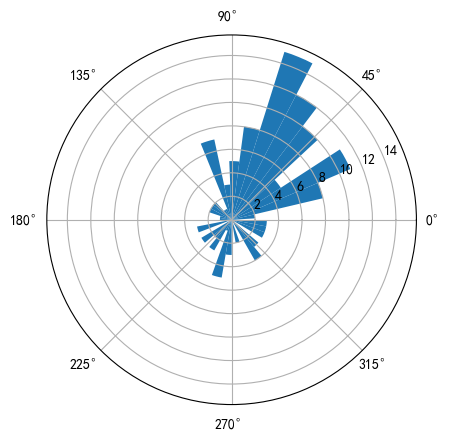

In [11]:
# 绘制风向玫瑰图
def plot_wind_rose(wind_dir, wind_speed):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.hist(np.deg2rad(wind_dir), bins=36)
    plt.show()

# 检查某个时刻所有风机的风向分布
t=10000
print(t)
plot_wind_rose(wind_direction[:, t], wind_speed[:, t])

In [12]:
import numpy as np
from scipy.stats import spearmanr
def compute_sector_spearman_correlation(
    wind_speed,
    sector_id,
    K=16,
    return_pvalues=False
):
    """
    对每个风向扇区，计算风机功率之间的 Spearman 相关性。
    
    Args:
        wind_speed (np.ndarray): Shape (N, T), 风机风速（归一化或原始值均可）
        sector_id (np.ndarray): Shape (T,), 每个时间步所属扇区（-1 表示无效）
        K (int): 扇区总数（如 16）
        return_pvalues (bool): 是否返回 p 值矩阵
    Returns:
        corr_matrices (list of np.ndarray): len=K, 每个元素 shape (N, N)
        n_samples (np.ndarray): shape (K,), 每个扇区的有效时间步数
        pval_matrices (optional): 同 corr_matrices，但为 p 值
    """
    N, T = wind_speed.shape
    assert sector_id.shape == (T,), "sector_id must be (T,)"

    corr_matrices = []
    pval_matrices = []
    n_samples = np.zeros(K, dtype=int)

    for k in range(K):
        # 获取扇区 k 的有效时间步索引
        t_idx = np.where(sector_id == k)[0]
        n_samples[k] = len(t_idx)
        
        # 提取该扇区下的风速子矩阵: (N, n_t)
        wind_speed_k = wind_speed[:, t_idx]  # shape (N, n_t)
        
        # 计算 Spearman 相关性（逐对）
        # 方法：转置后按列计算相关性（scipy 要求变量在行）
        corr_mat, pval_mat = spearmanr(wind_speed_k.T, axis=0)  # 返回 (N, N)
        
        # 处理可能的 NaN（如某风机全为常数）
        corr_mat = np.nan_to_num(corr_mat, nan=np.nan)
        pval_mat = np.nan_to_num(pval_mat, nan=1.0)
        
        corr_matrices.append(corr_mat)
        if return_pvalues:
            pval_matrices.append(pval_mat)
    
    if return_pvalues:
        return corr_matrices, n_samples, pval_matrices
    else:
        return corr_matrices, n_samples


=== 相关性统计信息 ===
相关系数范围: [0.553, 0.975]
平均相关系数: 0.845
相关系数标准差: 0.049
中位数相关系数: 0.843

相关性强度分布:
  强相关 (>0.7): 8782/8911 (98.6%)
  中等相关 (0.4-0.7): 129/8911 (1.4%)
  弱相关 (0.2-0.4): 0/8911 (0.0%)
  很弱相关 (≤0.2): 0/8911 (0.0%)

不同阈值下的连接统计:
  阈值 0.3: 8978/8911 (100.8%) 连接
  阈值 0.5: 8978/8911 (100.8%) 连接
  阈值 0.7: 8849/8911 (99.3%) 连接
  阈值 0.8: 7865/8911 (88.3%) 连接
  阈值 0.9: 1120/8911 (12.6%) 连接


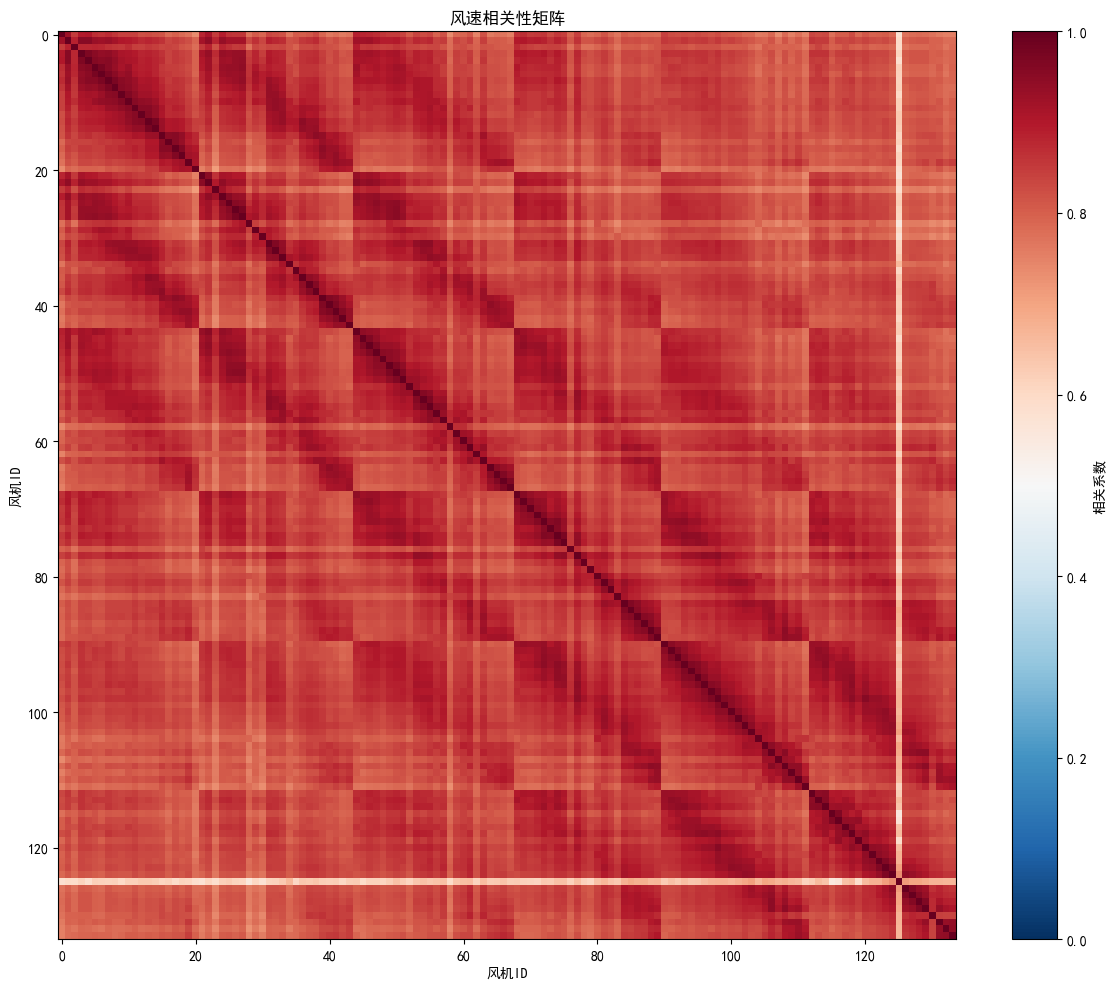

相关性矩阵图已保存为 sector_wind_speed_corr.png


In [14]:
sector_wind_speed_corr,n_samples = compute_sector_spearman_correlation(wind_speed, sectors)
print_correlation_stats(sector_wind_speed_corr[1])
visualize_correlation_matrix(sector_wind_speed_corr[1], save_path="sector_wind_speed_corr.png")
np.savez("sector_wind_speed_corr.npz", original=sector_wind_speed_corr)